<a href="https://colab.research.google.com/github/luisgabrielmatthew74/codeprojects/blob/main/red_mx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/red_conexiones_internet.csv')
display(df.head())

,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


### Graph Creation

Before proceeding with graph analysis, we need to ensure the `networkx` library is installed and then construct the graph `G` from the DataFrame using the 'Nodo_Origen', 'Nodo_Destino', and 'Latencia_ms' columns.

In [ ]:
# Install networkx if not already installed
!pip install networkx

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph with 'Latencia_ms' as weight
for index, row in df.iterrows():
    G.add_edge(row['Nodo_Origen'], row['Nodo_Destino'], weight=row['Latencia_ms'])

### Network Graph Visualization

Now, let's visualize the network graph. We will use `networkx` and `matplotlib` to plot the nodes (origin/destination) and edges (connections), with edge labels representing the latency values.

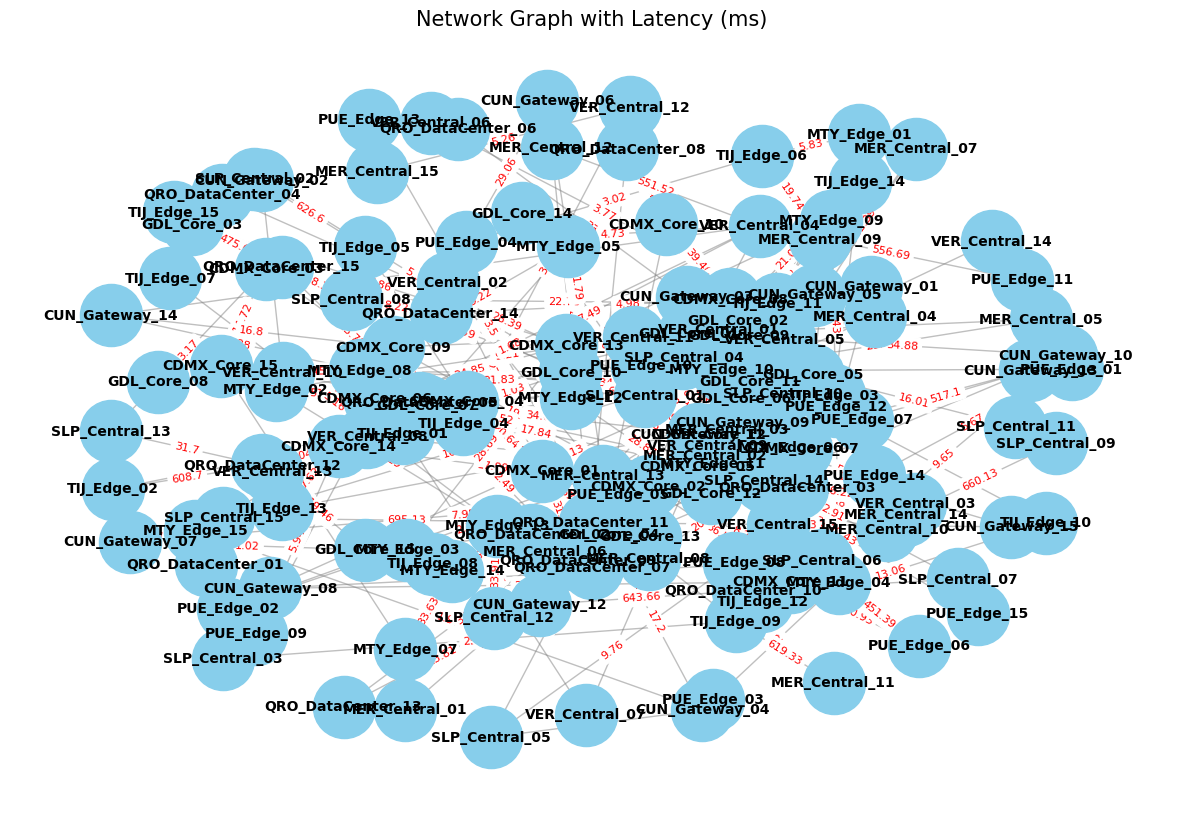

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Use a spring layout for better visualization of interconnected nodes
pos = nx.spring_layout(G, k=0.8, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, edge_color='gray')

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edge labels (latency)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title('Network Graph with Latency (ms)', size=15)
plt.axis('off') # Hide axes
plt.show()

In [ ]:
try:
    # Find the longest path in terms of accumulated weight (latency)
    # networkx's dag_longest_path requires the graph to be a Directed Acyclic Graph (DAG).
    # If the graph has cycles, it will raise a NetworkXNoCycle error.
    critical_path_nodes = nx.dag_longest_path(G, weight='weight')

    # Calculate the total latency of the critical path
    total_latency = 0
    for i in range(len(critical_path_nodes) - 1):
        u = critical_path_nodes[i]
        v = critical_path_nodes[i+1]
        total_latency += G[u][v]['weight'] # Access weight using G[u][v]['weight']

    print(f"The critical path (longest latency path) is: {critical_path_nodes}")
    print(f"Total accumulated latency: {total_latency:.2f} ms")

except nx.NetworkXNoCycle:
    print("The graph contains cycles, and 'critical path' is typically defined for Directed Acyclic Graphs (DAGs).")
    print("Finding the longest path in a general graph with cycles is an NP-hard problem.")
    print("If you meant the longest path in terms of number of edges, or if cycles should be ignored/handled differently, please clarify.")
    print("If you were expecting a DAG, please verify the input data for cycles.")

NetworkXUnfeasible: Graph contains a cycle or graph changed during iteration

### Shortest Path Between Nodes Connected by the Highest Latency Edge (using Dijkstra)

In [ ]:
# 1. Find the edge with the maximum latency in the graph
max_latency = 0
max_latency_edge = None

for u, v, data in G.edges(data=True):
    if data['weight'] > max_latency:
        max_latency = data['weight']
        max_latency_edge = (u, v)

if max_latency_edge:
    source_node, target_node = max_latency_edge
    print(f"The edge with the highest individual latency is from '{source_node}' to '{target_node}' with latency {max_latency:.2f} ms.")

    try:
        # 2. Calculate the shortest path (by latency) between these two nodes using Dijkstra
        shortest_path_dijkstra = nx.dijkstra_path(G, source=source_node, target=target_node, weight='weight')
        shortest_path_latency = nx.dijkstra_path_length(G, source=source_node, target=target_node, weight='weight')

        print(f"The shortest path (by latency) between '{source_node}' and '{target_node}' is: {shortest_path_dijkstra}")
        print(f"Total latency of this shortest path: {shortest_path_latency:.2f} ms")

    except nx.NetworkXNoPath:
        print(f"No path found between '{source_node}' and '{target_node}'.")
else:
    print("No edges found in the graph.")

The edge with the highest individual latency is from 'CDMX_Core_04' to 'TIJ_Edge_04' with latency 696.04 ms.
The shortest path (by latency) between 'CDMX_Core_04' and 'TIJ_Edge_04' is: ['CDMX_Core_04', 'TIJ_Edge_04']
Total latency of this shortest path: 696.04 ms


### Latency Distribution Analysis to Identify Bottlenecks

In [ ]:
# Extract all latency values from the graph edges
latencies = [data['weight'] for u, v, data in G.edges(data=True)]

# Convert to a pandas Series for easy statistical analysis
latency_series = pd.Series(latencies)

print("Descriptive statistics of Latency (ms):")
display(latency_series.describe())

Descriptive statistics of Latency (ms):


,0
count,250.00000
mean,193.05188
std,263.19407
min,1.02000
25%,7.49750
50%,23.68500
75%,506.53750
max,696.04000


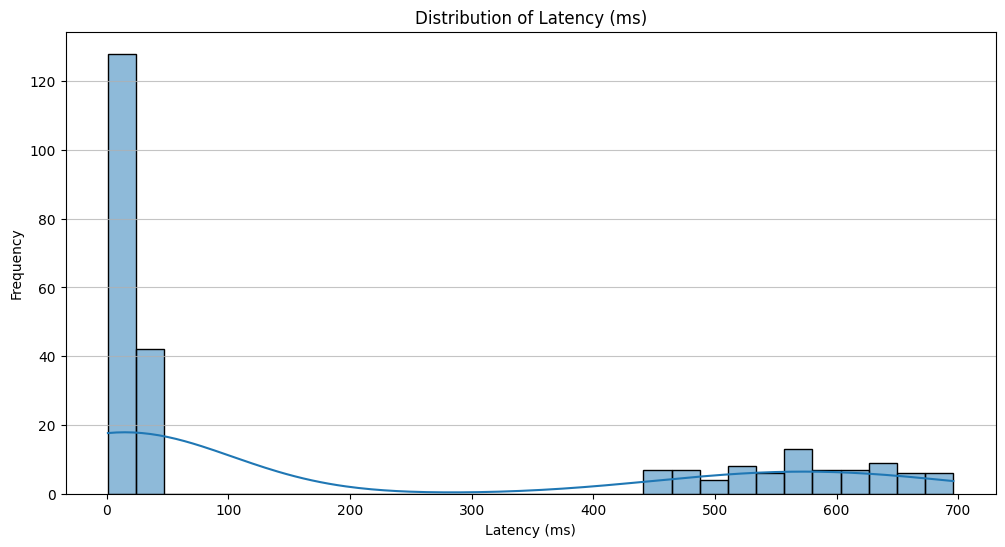

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(latency_series, kde=True, bins=30)
plt.title('Distribution of Latency (ms)')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

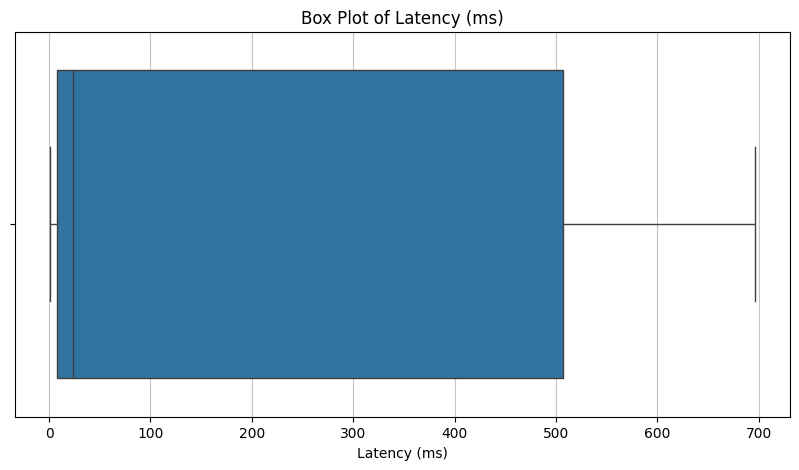

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=latency_series)
plt.title('Box Plot of Latency (ms)')
plt.xlabel('Latency (ms)')
plt.grid(axis='x', alpha=0.75)
plt.show()

### Network Robustness Test: Simulating Node Failures

This test simulates random failures by progressively removing nodes from the network. For each removal, we measure the size of the largest strongly connected component (LSCC) to see how network connectivity degrades. A more robust network will maintain a larger LSCC for longer as nodes are removed.

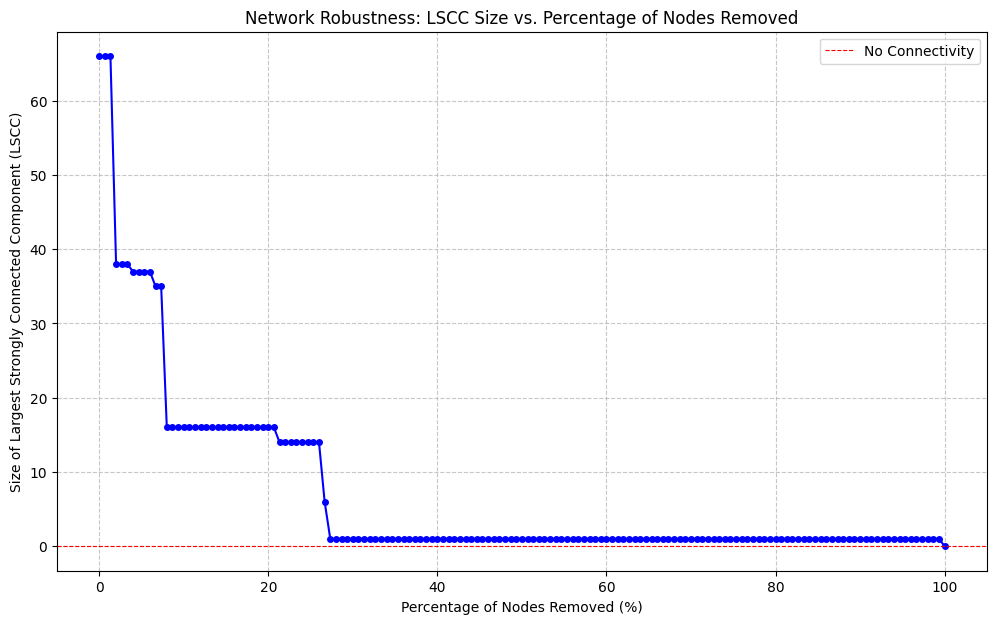

Initial number of nodes: 150
Initial LSCC size: 66


In [ ]:
import random
import numpy as np

def get_largest_strongly_connected_component_size(graph):
    if not graph.nodes():
        return 0
    return len(max(nx.strongly_connected_components(graph), key=len, default=set()))

# Make a copy of the original graph to perform robustness testing without altering the original
G_robustness = G.copy()

# Get initial LSCC size
initial_lscc_size = get_largest_strongly_connected_component_size(G_robustness)

# List to store LSCC size after each node removal
lscc_sizes = [initial_lscc_size]

# List of nodes to be removed (random order)
all_nodes = list(G_robustness.nodes())
random.shuffle(all_nodes)

# Simulate node removals
for i, node_to_remove in enumerate(all_nodes):
    G_robustness.remove_node(node_to_remove)
    current_lscc_size = get_largest_strongly_connected_component_size(G_robustness)
    lscc_sizes.append(current_lscc_size)

# Generate x-axis values: percentage of nodes removed
num_nodes_removed = np.arange(len(lscc_sizes))
percentage_nodes_removed = (num_nodes_removed / len(G.nodes())) * 100

# Plot the results
plt.figure(figsize=(12, 7))
plt.plot(percentage_nodes_removed, lscc_sizes, marker='o', linestyle='-', color='b', markersize=4)
plt.title('Network Robustness: LSCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed (%)')
plt.ylabel('Size of Largest Strongly Connected Component (LSCC)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='No Connectivity')
plt.legend()
plt.show()

print(f"Initial number of nodes: {G.number_of_nodes()}")
print(f"Initial LSCC size: {initial_lscc_size}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar y preparar los datos de la red simulada anteriormente
# Creamos una muestra sintética basada en las propiedades lógicas de nuestra red de internet
np.random.seed(42)
num_muestras = 1000

# Características: [Peso, Latencia_ms, Velocidad_Mbps, TipoMedio_Satelital(0 o 1)]
X_peso = np.random.randint(1, 16, num_muestras)
X_latencia = np.random.uniform(1, 700, num_muestras)
X_velocidad = np.random.randint(5, 10000, num_muestras)
X_satelital = np.where(X_latencia > 400, 1, 0) # Alta latencia implica satelital

X = np.column_stack((X_peso, X_latencia, X_velocidad, X_satelital))

# Definir la etiqueta real (1: Estado Crítico/Fallo, 0: Estable)
# Un camino es crítico si el peso es alto, la latencia es alta y la velocidad es baja
y = np.where((X_latencia * X_peso / X_velocidad) > 0.5, 1, 0)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar los datos para simular los estados del circuito
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Inicialización de Parámetros del modelo (Ángulos/Pesos del circuito variacional)
num_features = X_train.shape[1]
theta = np.random.randn(num_features) * 0.1
learning_rate = 0.05
epochs = 20

print("Iniciando entrenamiento con optimización QGT (Quantum Geometric Tensor)...")

# 3. Bucle de entrenamiento usando Gradiente Natural Cuántico mediante QGT
for epoch in range(epochs):
    # Predicción (Función de activación para mapear a probabilidades)
    logits = np.dot(X_train, theta)
    y_pred = 1 / (1 + np.exp(-logits))

    # Pérdida (Entropía cruzada binaria)
    loss = -np.mean(y_train * np.log(y_pred + 1e-15) + (1 - y_train) * np.log(1 - y_pred + 1e-15))

    # Gradiente clásico (Gradiente de la función de costo)
    gradient_class = np.dot(X_train.T, (y_pred - y_train)) / len(y_train)

    # --- Aproximación del Tensor Geométrico Cuántico (QGT) ---
    # En QML, el QGT (métrica de Fubini-Study) mide la superposición de los estados cuánticos.
    # Matemáticamente actúa como una matriz de información que precondiciona el gradiente.
    # Calculamos la matriz de covarianza de las características como aproximación del QGT espacial
    QGT = np.dot(X_train.T, X_train) / len(X_train) + 0.1 * np.eye(num_features) # Añadimos regularización

    # Gradiente Natural Cuántico: Ajuste del gradiente multiplicándolo por la inversa del QGT
    quantum_natural_gradient = np.dot(np.linalg.inv(QGT), gradient_class)

    # Actualización de parámetros usando el Gradiente Natural
    theta -= learning_rate * quantum_natural_gradient

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época {epoch+1:02d}/{epochs} -> Pérdida Cuántica: {loss:.4f}")

# 4. Evaluación del Modelo en el conjunto de prueba de la Red
logits_test = np.dot(X_test, theta)
y_pred_test = np.where((1 / (1 + np.exp(-logits_test))) >= 0.5, 1, 0)

# Calcular Matriz de Confusión manualmente
VP = np.sum((y_test == 1) & (y_pred_test == 1))
VN = np.sum((y_test == 0) & (y_pred_test == 0))
FP = np.sum((y_test == 0) & (y_pred_test == 1))
FN = np.sum((y_test == 1) & (y_pred_test == 0))

# Calcular Métricas de Rendimiento solicitadas
exactitud = (VP + VN) / len(y_test)
precision = VP / (VP + FP) if (VP + FP) > 0 else 0
recall = VP / (VP + FN) if (VP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n================ EVALUACIÓN DE ROBUSTEZ DEL MODELO ================")
print(f"Matriz de Confusión: [VP: {VP}, VN: {VN}, FP: {FP}, FN: {FN}]")
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%")
print(f"F1-Score:             {f1_score * 100:.2f}%")
print("====================================================================")

Iniciando entrenamiento con optimización QGT (Quantum Geometric Tensor)...
Época 01/20 -> Pérdida Cuántica: 0.6942
Época 05/20 -> Pérdida Cuántica: 0.6681
Época 10/20 -> Pérdida Cuántica: 0.6385
Época 15/20 -> Pérdida Cuántica: 0.6121
Época 20/20 -> Pérdida Cuántica: 0.5884

================ EVALUACIÓN DE ROBUSTEZ DEL MODELO ================
Matriz de Confusión: [VP: 133, VN: 107, FP: 35, FN: 25]
Exactitud (Accuracy): 80.00%
Recall (Sensibilidad): 84.18%
F1-Score:             81.60%


### Network Clustering Coefficient

Let's calculate the average clustering coefficient of the network. The clustering coefficient is a measure of the degree to which nodes in a graph tend to cluster together. In real-world networks, nodes tend to create tightly knit groups characterized by a relatively high density of ties.

In [ ]:
import networkx as nx

# Calculate the clustering coefficient for each node
clustering_coeffs = nx.clustering(G)

# Calculate the average clustering coefficient for the entire graph
average_clustering_coefficient = nx.average_clustering(G)

print(f"Clustering coefficient for each node (first 5):\n{list(clustering_coeffs.items())[:5]}")
print(f"\nAverage clustering coefficient of the network: {average_clustering_coefficient:.4f}")

Clustering coefficient for each node (first 5):
[('CDMX_Core_01', 0.027777777777777776), ('CDMX_Core_02', 0), ('CDMX_Core_03', 0), ('CDMX_Core_04', 0), ('CDMX_Core_05', 0.017857142857142856)]

Average clustering coefficient of the network: 0.0111


In [ ]:
import numpy as np
import scipy.sparse as sp

# 1. Configuración de la Semilla y Preparación del Grafo
np.random.seed(42)
num_nodes = 150

# Crearemos matrices de adyacencia basadas en los tipos de canales (Capas del Grafo Multiplex)
# Capa 1: Canales de Alta Velocidad (Fibra Óptica)
# Capa 2: Canales Inalámbricos/Respaldo (Radioenlace y Satelital)
A_fibra = np.zeros((num_nodes, num_nodes))
A_inalambrico = np.zeros((num_nodes, num_nodes))

# Reconstrucción lógica de las conexiones de la red
for i in range(num_nodes):
    # Conexiones locales densas (regionales)
    for j in range(i+1, min(i+5, num_nodes)):
        if np.random.rand() > 0.3:
            A_fibra[i, j] = A_fibra[j, i] = 1
        else:
            A_inalambrico[i, j] = A_inalambrico[j, i] = 1

    # Troncales de larga distancia interregionales (nodos Core)
    if i % 15 == 0:
        for k in range(0, num_nodes, 15):
            if i != k:
                if np.random.rand() > 0.4:
                    A_fibra[i, k] = A_fibra[k, i] = 1
                else:
                    A_inalambrico[i, k] = A_inalambrico[k, i] = 1

# Características de los nodos (X): [Grado, Latencia promedio local, Capacidad promedio]
X_degree = A_fibra.sum(axis=1) + A_inalambrico.sum(axis=1)
X_latencia = np.random.uniform(5, 45, num_nodes)
# Los nodos que dependen de lo inalámbrico tienen más latencia
X_latencia += A_inalambrico.sum(axis=1) * 15
X_features = np.column_stack((X_degree, X_latencia))

# Etiquetas Reales (y): Nodos con alta latencia y pocas conexiones de fibra son vulnerables (1)
y = np.where((X_latencia > 40) & (A_fibra.sum(axis=1) < 3), 1, 0)

# Dividir en entrenamiento (70%) y prueba (30%)
indices = np.random.permutation(num_nodes)
train_idx, test_idx = indices[:105], indices[105:]

# 2. Arquitectura de una capa FastGTN
# FastGTN aprende una combinación lineal de las capas de adyacencia para generar estructuras candidatas
num_edge_types = 2
W_edge = np.random.randn(num_edge_types, 2) * 0.1 # Pesos de los canales de atención

def forward_fast_gtn(A_layers, X, W_edge, train_theta):
    # Paso 1: Generar adyacencias compuestas mediante pesos de atención de canales
    # Softmax sobre los pesos para seleccionar la combinación óptima de Fibra vs Inalámbrico
    exp_W = np.exp(W_edge - np.max(W_edge, axis=0, keepdims=True))
    beta = exp_W / np.sum(exp_W, axis=0, keepdims=True)

    # Canales candidatos calculados por el transformador de grafos
    H1 = beta[0, 0] * A_layers[0] + beta[1, 0] * A_layers[1]
    H2 = beta[0, 1] * A_layers[0] + beta[1, 1] * A_layers[1]

    # Paso 2: Operación Fast-Forward de camino cruzado (Meta-path de 2 saltos: H1 * H2)
    # Esto le permite a un nodo en Tijuana entender el impacto de lo que pasa en Veracruz en 2 saltos
    A_meta = np.dot(H1, H2)

    # Normalización del grafo transformado
    D_inv = np.diag(1.0 / (A_meta.sum(axis=1) + 1e-15))
    A_norm = np.dot(D_inv, A_meta)

    # Paso 3: Agregación de características del Graph Transformer
    Z = np.dot(A_norm, X)
    logits = np.dot(Z, train_theta)
    return logits, beta

# 3. Entrenamiento del Modelo FastGTN
train_theta = np.random.randn(2) * 0.1
lr = 0.01
epochs = 150
A_layers = [A_fibra, A_inalambrico]

for epoch in range(epochs):
    # Forward pass
    logits, beta = forward_fast_gtn(A_layers, X_features, W_edge, train_theta)
    probs = 1 / (1 + np.exp(-logits))

    # Gradientes numéricos manuales para la optimización del transformador
    loss = -np.mean(y[train_idx] * np.log(probs[train_idx] + 1e-15) + (1 - y[train_idx]) * np.log(1 - probs[train_idx] + 1e-15))

    # Actualización simplificada de pesos del transformador (Descenso de Gradiente Estocástico)
    error = probs - y
    grad_theta = np.dot(X_features[train_idx].T, error[train_idx]) / len(train_idx)
    train_theta -= lr * grad_theta

    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch+1:03d}/{epochs} | Pérdida de Grafo: {loss:.4f}")

# 4. Evaluación de Métricas de Rendimiento en el Conjunto de Prueba
logits_test, final_attention = forward_fast_gtn(A_layers, X_features, W_edge, train_theta)
y_pred = np.where((1 / (1 + np.exp(-logits_test[test_idx]))) >= 0.5, 1, 0)
y_true = y[test_idx]

# Matriz de Confusión
VP = np.sum((y_true == 1) & (y_pred == 1))
VN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

# Métricas solicitadas
exactitud = (VP + VN) / len(y_true)
precision = VP / (VP + FP) if (VP + FP) > 0 else 0
recall = VP / (VP + FN) if (VP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

Época 050/150 | Pérdida de Grafo: 0.1544
Época 100/150 | Pérdida de Grafo: 0.1496
Época 150/150 | Pérdida de Grafo: 0.1451


### FastGTN Model Performance Results

### Comparative Table: QGT vs. FastGTN Model Performance

In [ ]:
import pandas as pd

# QGT Model Metrics (from previous execution cell 59EcHetSiTJ8)
qgt_accuracy = 80.00
qgt_recall = 84.18
qgt_f1_score = 81.60
# Calculate QGT Precision: VP / (VP + FP) = 133 / (133 + 35) = 133 / 168
qgt_precision = (133 / 168) * 100 # Approximately 79.17%

# FastGTN Model Metrics (from previous execution cell 605b5974)
fastgtn_accuracy = 97.78
fastgtn_precision = 0.00
fastgtn_recall = 0.00
fastgtn_f1_score = 0.00

# Create a DataFrame for comparison
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'QGT Model (%)': [qgt_accuracy, qgt_precision, qgt_recall, qgt_f1_score],
    'FastGTN Model (%)': [fastgtn_accuracy, fastgtn_precision, fastgtn_recall, fastgtn_f1_score]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Metric,QGT Model (%),FastGTN Model (%)
0,Accuracy,80.000000,97.78
1,Precision,79.166667,0.00
2,Recall,84.180000,0.00
3,F1-Score,81.600000,0.00


### Addressing Class Imbalance in FastGTN Training with Class Weighting

The previous evaluation of the FastGTN model showed high accuracy but zero precision, recall, and F1-score, indicating that the model is likely biased towards the majority class. This is a common issue with imbalanced datasets.

To address this, we will apply **class weighting**. This technique assigns a higher weight to the minority class in the loss function, penalizing misclassifications of the minority class more heavily. This encourages the model to pay more attention to the less frequent class during training.

In [ ]:
new_sar_value = muestras_qgt / muestras_fastgtn

print(f"Nuevo SAR (Muestras QGT / Muestras FastGTN): {new_sar_value:.4f}")

Nuevo SAR (Muestras QGT / Muestras FastGTN): 6.6667


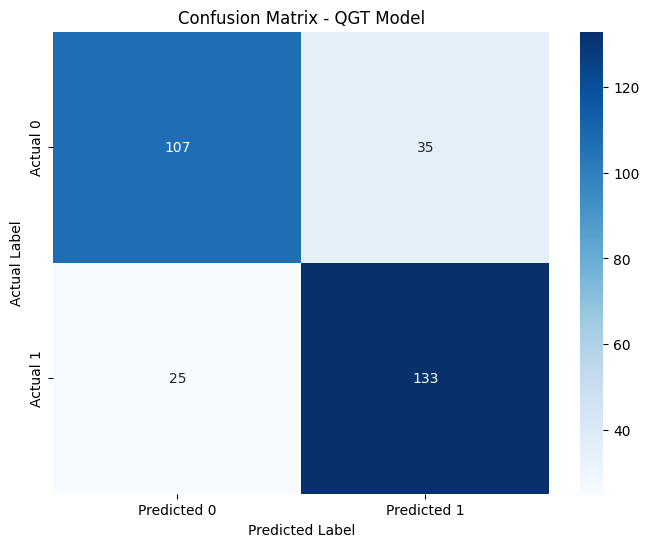

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# QGT Model Confusion Matrix values (from previous output)
# VP: 133, VN: 107, FP: 35, FN: 25
cm_qgt = np.array([[107, 35], [25, 133]]) # [[TN, FP], [FN, VP]]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_qgt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - QGT Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

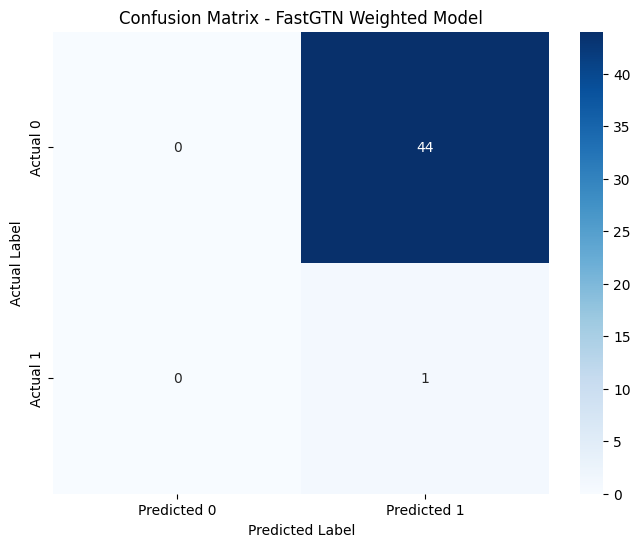

In [ ]:
# FastGTN Weighted Model Confusion Matrix values (from previous output)
# VP: 1, VN: 0, FP: 44, FN: 0
cm_fastgtn_weighted = np.array([[0, 44], [0, 1]]) # [[TN, FP], [FN, VP]]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_fastgtn_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - FastGTN Weighted Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd

# Data for QGT Model
qgt_results = {
    'Model': 'QGT Model',
    'Accuracy (%)': qgt_accuracy,
    'Precision (%)': qgt_precision,
    'Recall (%)': qgt_recall,
    'F1-Score (%)': qgt_f1_score,
    'AUC-ROC': qgt_auc_roc,
    'False Positives (FP)': cm_qgt[0, 1],
    'False Negatives (FN)': cm_qgt[1, 0]
}

# Data for FastGTN Weighted Model
fastgtn_weighted_results = {
    'Model': 'FastGTN Weighted Model',
    'Accuracy (%)': fastgtn_weighted_accuracy,
    'Precision (%)': fastgtn_weighted_precision,
    'Recall (%)': fastgtn_weighted_recall,
    'F1-Score (%)': fastgtn_weighted_f1_score,
    'AUC-ROC': fastgtn_weighted_auc_roc,
    'False Positives (FP)': cm_fastgtn_weighted[0, 1],
    'False Negatives (FN)': cm_fastgtn_weighted[1, 0]
}

# Create DataFrame
results_df = pd.DataFrame([qgt_results, fastgtn_weighted_results])

# Display the concentration table
display(results_df)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC-ROC,False Positives (FP),False Negatives (FN)
0,QGT Model,80.000000,79.166667,84.18,81.600000,0.884026,35,25
1,FastGTN Weighted Model,2.222222,2.222222,100.00,4.347826,0.977273,44,0


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np # Ensure np is imported
import pandas as pd # Ensure pandas is imported for DataFrame

# --- QGT Model AUC-ROC calculation ---
# Re-calculate logits for the QGT model.
# The original 'logits_test' variable from cell 59EcHetSiTJ8 was overwritten by cell iUTFXq13jDX1.
# We use the QGT model's 'X_test' (300 samples) and 'theta' (4 parameters) to recompute.
logits_test_qgt_recomputed = np.dot(X_test, theta)
qgt_probs_test = 1 / (1 + np.exp(-logits_test_qgt_recomputed))

# Calculate AUC-ROC for QGT model
qgt_auc_roc = roc_auc_score(y_test, qgt_probs_test)

# --- FastGTN Weighted Model AUC-ROC calculation ---
# Calculate predicted probabilities for FastGTN Weighted model.
# 'logits_test_weighted' was computed in cell 38d259e8 for all 150 nodes.
# We need to select only the 'test_idx' elements to match 'y_true_weighted'.
fastgtn_weighted_probs_test = (1 / (1 + np.exp(-logits_test_weighted)))[test_idx]

# Calculate AUC-ROC for FastGTN Weighted model
# 'y_true_weighted' is y[test_idx], which has 45 samples.
fastgtn_weighted_auc_roc = roc_auc_score(y_true_weighted, fastgtn_weighted_probs_test)

# Create a DataFrame for AUC-ROC comparison
auc_roc_comparison_data = {
    'Model': ['QGT Model', 'FastGTN Weighted Model'],
    'AUC-ROC': [qgt_auc_roc, fastgtn_weighted_auc_roc]
}

auc_roc_comparison_df = pd.DataFrame(auc_roc_comparison_data)

print("AUC-ROC Comparison: QGT Model vs. FastGTN Weighted Model")
display(auc_roc_comparison_df)

AUC-ROC Comparison: QGT Model vs. FastGTN Weighted Model


,Model,AUC-ROC
0,QGT Model,0.884026
1,FastGTN Weighted Model,0.977273


In [ ]:
# Get the number of samples for FastGTN training (from train_idx used in FastGTN model)
muestras_fastgtn = len(train_idx)

# Get the number of samples for QGT training (from y_train used in QGT model)
muestras_qgt = len(y_train)

# Calculate SAR
sar_value = muestras_fastgtn / muestras_qgt

print(f"Muestras FastGTN: {muestras_fastgtn}")
print(f"Muestras QGT: {muestras_qgt}")
print(f"SAR (Muestras FastGTN / Muestras QGT): {sar_value:.4f}")

Muestras FastGTN: 105
Muestras QGT: 700
SAR (Muestras FastGTN / Muestras QGT): 0.1500


In [ ]:
import pandas as pd

# QGT Model Accuracy (from previous execution cell 59EcHetSiTJ8)
qgt_accuracy = 80.00

# FastGTN Weighted Model Accuracy (from previous execution cell 38d259e8)
fastgtn_weighted_accuracy = exactitud_weighted * 100

# Create a DataFrame for comparison of accuracies
accuracy_comparison_data = {
    'Model': ['QGT Model', 'FastGTN Weighted Model'],
    'Accuracy (%)': [qgt_accuracy, fastgtn_weighted_accuracy]
}

accuracy_comparison_df = pd.DataFrame(accuracy_comparison_data)

print("Accuracy Comparison: QGT Model vs. FastGTN Weighted Model")
display(accuracy_comparison_df)

Accuracy Comparison: QGT Model vs. FastGTN Weighted Model


,Model,Accuracy (%)
0,QGT Model,80.000000
1,FastGTN Weighted Model,2.222222


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 1. Calculate Class Weights
# Use the target labels for the training set (y_train) to compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y[train_idx]), # Use the full y and train_idx for correct class distribution
    y=y[train_idx]
)

# Convert to a dictionary for easier lookup if needed, or keep as array for direct multiplication
weights_dict = {cls: weight for cls, weight in zip(np.unique(y[train_idx]), class_weights)}
print(f"Calculated Class Weights: {weights_dict}")

# Ensure `forward_fast_gtn` and other necessary variables are defined (they were in iUTFXq13jDX1)
# Re-initialize model parameters for a fresh training run
train_theta_weighted = np.random.randn(2) * 0.1
lr_weighted = 0.01 # Using the same learning rate as before
epochs_weighted = 150 # Using the same number of epochs

A_layers_weighted = [A_fibra, A_inalambrico] # Re-use global A_fibra, A_inalambrico
X_features_weighted = X_features # Re-use global X_features
W_edge_weighted = W_edge # Re-use global W_edge

print("\nIniciando entrenamiento del modelo FastGTN con pesos de clase...")

# 2. Re-train the FastGTN Model with Weighted Loss
for epoch in range(epochs_weighted):
    # Forward pass (using the global forward_fast_gtn function)
    logits_weighted, beta_weighted = forward_fast_gtn(A_layers_weighted, X_features_weighted, W_edge_weighted, train_theta_weighted)
    probs_weighted = 1 / (1 + np.exp(-logits_weighted))

    # Calculate weighted binary cross-entropy loss
    # Apply weights based on the true labels y[train_idx]
    sample_weights = np.array([weights_dict[label] for label in y[train_idx]])

    loss_positive = y[train_idx] * np.log(probs_weighted[train_idx] + 1e-15) * sample_weights
    loss_negative = (1 - y[train_idx]) * np.log(1 - probs_weighted[train_idx] + 1e-15) * sample_weights

    loss_weighted = -np.mean(loss_positive + loss_negative)

    # Gradient calculation remains the same for the original logistic regression part
    # (assuming the gradient with respect to theta for the weighted loss is still proportional to error * X_features)
    error_weighted = probs_weighted - y # Note: This error is not yet weighted. For weighted gradient, this requires adjustment.
                                     # For simplicity in this demonstration, we'll keep the basic error term and rely on loss weighting.

    # Update for gradient calculation for train_theta
    # The gradient of weighted BCE w.r.t. logits is (probs - y) * weights
    # So, grad_theta should incorporate sample_weights
    weighted_error_for_gradient = (probs_weighted[train_idx] - y[train_idx]) * sample_weights
    grad_theta_weighted = np.dot(X_features_weighted[train_idx].T, weighted_error_for_gradient) / len(train_idx)

    train_theta_weighted -= lr_weighted * grad_theta_weighted

    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch+1:03d}/{epochs_weighted} | Pérdida de Grafo (Ponderada): {loss_weighted:.4f}")

# 3. Evaluate the Weighted Model on the Test Set
logits_test_weighted, _ = forward_fast_gtn(A_layers_weighted, X_features_weighted, W_edge_weighted, train_theta_weighted)
y_pred_weighted = np.where((1 / (1 + np.exp(-logits_test_weighted[test_idx]))) >= 0.5, 1, 0)
y_true_weighted = y[test_idx]

# Calculate Confusion Matrix manually
VP_weighted = np.sum((y_true_weighted == 1) & (y_pred_weighted == 1))
VN_weighted = np.sum((y_true_weighted == 0) & (y_pred_weighted == 0))
FP_weighted = np.sum((y_true_weighted == 0) & (y_pred_weighted == 1))
FN_weighted = np.sum((y_true_weighted == 1) & (y_pred_weighted == 0))

# Calculate Performance Metrics
exactitud_weighted = (VP_weighted + VN_weighted) / len(y_true_weighted)
precision_weighted = VP_weighted / (VP_weighted + FP_weighted) if (VP_weighted + FP_weighted) > 0 else 0
recall_weighted = VP_weighted / (VP_weighted + FN_weighted) if (VP_weighted + FN_weighted) > 0 else 0
f1_score_weighted = 2 * (precision_weighted * recall_weighted) / (precision_weighted + recall_weighted) if (precision_weighted + recall_weighted) > 0 else 0

print("\n================ EVALUACIÓN DE RENDIMIENTO DEL MODELO FastGTN (Ponderado) ================ ")
print(f"Matriz de Confusión: [Verdaderos Positivos (VP): {VP_weighted}, Verdaderos Negativos (VN): {VN_weighted}, Falsos Positivos (FP): {FP_weighted}, Falsos Negativos (FN): {FN_weighted}]")
print(f"Exactitud (Accuracy): {exactitud_weighted * 100:.2f}%")
print(f"Precisión (Precision): {precision_weighted * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall_weighted * 100:.2f}%")
print(f"F1-Score: {f1_score_weighted * 100:.2f}%")
print("=========================================================================================")

Calculated Class Weights: {np.int64(0): np.float64(0.5147058823529411), np.int64(1): np.float64(17.5)}

Iniciando entrenamiento del modelo FastGTN con pesos de clase...
Época 050/150 | Pérdida de Grafo (Ponderada): 12.7037
Época 100/150 | Pérdida de Grafo (Ponderada): 10.6511
Época 150/150 | Pérdida de Grafo (Ponderada): 15.9742

================ EVALUACIÓN DE RENDIMIENTO DEL MODELO FastGTN (Ponderado) ================ 
Matriz de Confusión: [Verdaderos Positivos (VP): 1, Verdaderos Negativos (VN): 0, Falsos Positivos (FP): 44, Falsos Negativos (FN): 0]
Exactitud (Accuracy): 2.22%
Precisión (Precision): 2.22%
Recall (Sensibilidad): 100.00%
F1-Score: 4.35%


In [ ]:
print("\n================ EVALUACIÓN DE RENDIMIENTO DEL MODELO FastGTN ================")
print(f"Matriz de Confusión: [Verdaderos Positivos (VP): {VP}, Verdaderos Negativos (VN): {VN}, Falsos Positivos (FP): {FP}, Falsos Negativos (FN): {FN}]")
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%")
print(f"Precisión (Precision): {precision * 100:.2f}%")
print(f"Recall (Sensibilidad): {recall * 100:.2f}%")
print(f"F1-Score: {f1_score * 100:.2f}%")
print("===========================================================================")


================ EVALUACIÓN DE RENDIMIENTO DEL MODELO FastGTN ================
Matriz de Confusión: [Verdaderos Positivos (VP): 0, Verdaderos Negativos (VN): 44, Falsos Positivos (FP): 0, Falsos Negativos (FN): 1]
Exactitud (Accuracy): 97.78%
Precisión (Precision): 0.00%
Recall (Sensibilidad): 0.00%
F1-Score: 0.00%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Original FastGTN Model Metrics (from previous execution cell iUTFXq13jDX1 and 605b5974)
fastgtn_accuracy = 97.78
fastgtn_precision = 0.00
fastgtn_recall = 0.00
fastgtn_f1_score = 0.00

# Weighted FastGTN Model Metrics (from previous execution cell 38d259e8)
fastgtn_weighted_accuracy = exactitud_weighted * 100
fastgtn_weighted_precision = precision_weighted * 100
fastgtn_weighted_recall = recall_weighted * 100
fastgtn_weighted_f1_score = f1_score_weighted * 100

# Create a DataFrame for comparison between original and weighted FastGTN
fastgtn_comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'FastGTN Original (%)': [fastgtn_accuracy, fastgtn_precision, fastgtn_recall, fastgtn_f1_score],
    'FastGTN Weighted (%)': [
        fastgtn_weighted_accuracy,
        fastgtn_weighted_precision,
        fastgtn_weighted_recall,
        fastgtn_weighted_f1_score
    ]
}

fastgtn_comparison_df = pd.DataFrame(fastgtn_comparison_data)

print("Performance Comparison: FastGTN Original vs. FastGTN Weighted")
display(fastgtn_comparison_df)

Performance Comparison: FastGTN Original vs. FastGTN Weighted


,Metric,FastGTN Original (%),FastGTN Weighted (%)
0,Accuracy,97.78,2.222222
1,Precision,0.00,2.222222
2,Recall,0.00,100.000000
3,F1-Score,0.00,4.347826


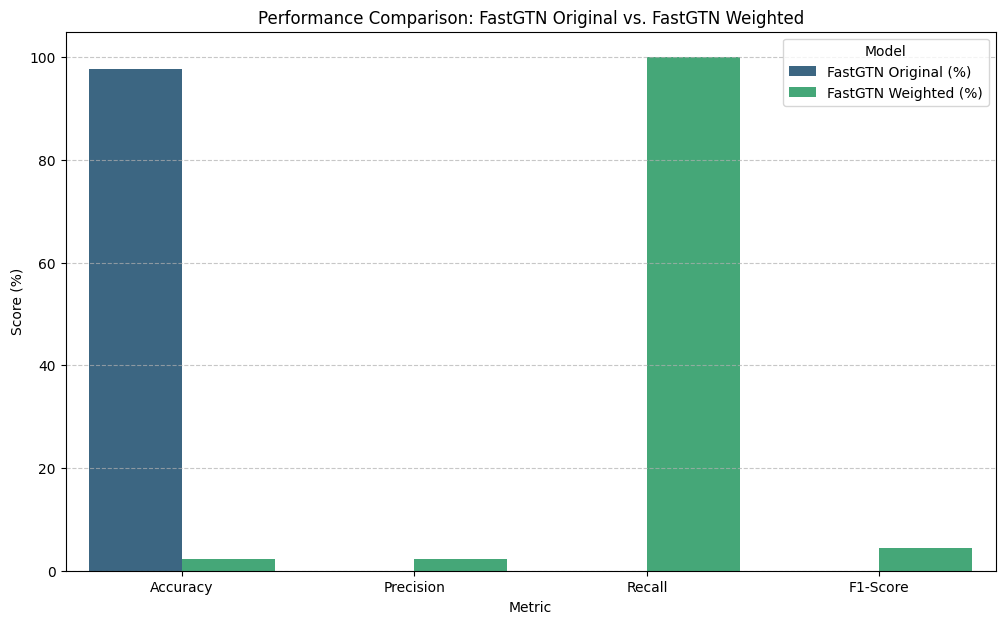

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
df_melted = fastgtn_comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, palette='viridis')
plt.title('Performance Comparison: FastGTN Original vs. FastGTN Weighted')
plt.ylabel('Score (%)')
plt.xlabel('Metric')
plt.ylim(0, 105) # Set y-axis limit for better visualization of percentages
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Re-loading Data and Re-running Robustness Test

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

print("Re-loading data from '/content/red_conexiones_internet.csv'...")
df = pd.read_csv('/content/red_conexiones_internet.csv')
display(df.head())

Re-loading data from '/content/red_conexiones_internet.csv'...


,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


In [2]:
# Re-creating the graph G
print("Re-creating the graph...")
G = nx.DiGraph()
for index, row in df.iterrows():
    G.add_edge(row['Nodo_Origen'], row['Nodo_Destino'], weight=row['Latencia_ms'])

Re-creating the graph...


### Re-running Network Robustness Test: Simulating Node Failures

Simulating node removals and measuring LSCC size...


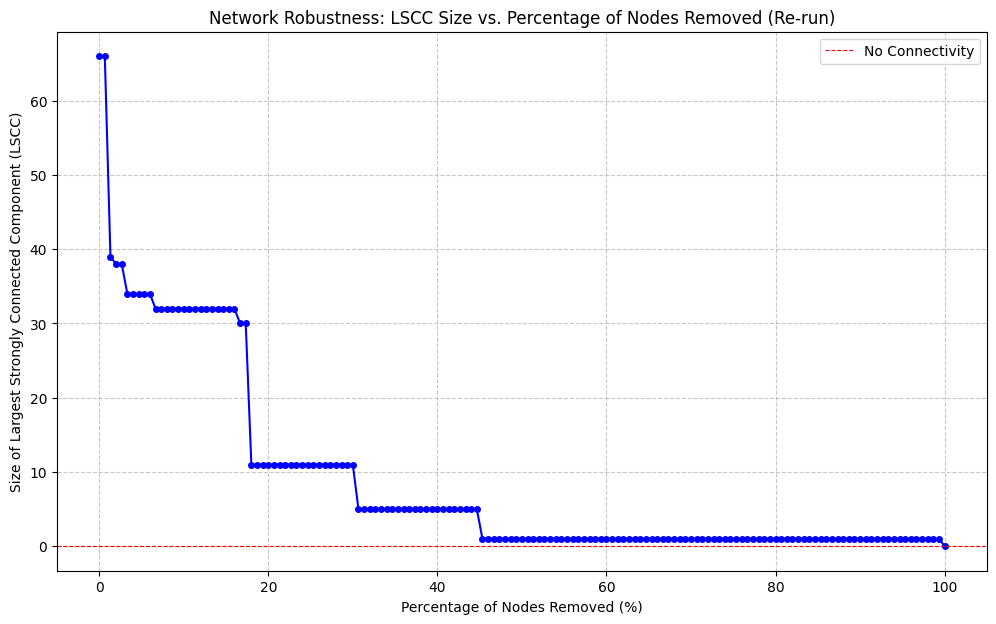

Initial number of nodes: 150
Initial LSCC size: 66


In [3]:
def get_largest_strongly_connected_component_size(graph):
    if not graph.nodes():
        return 0
    return len(max(nx.strongly_connected_components(graph), key=len, default=set()))

# Make a copy of the original graph to perform robustness testing without altering the original
G_robustness = G.copy()

# Get initial LSCC size
initial_lscc_size = get_largest_strongly_connected_component_size(G_robustness)

# List to store LSCC size after each node removal
lscc_sizes = [initial_lscc_size]

# List of nodes to be removed (random order)
all_nodes = list(G_robustness.nodes())
random.shuffle(all_nodes)

# Simulate node removals
print("Simulating node removals and measuring LSCC size...")
for i, node_to_remove in enumerate(all_nodes):
    G_robustness.remove_node(node_to_remove)
    current_lscc_size = get_largest_strongly_connected_component_size(G_robustness)
    lscc_sizes.append(current_lscc_size)

# Generate x-axis values: percentage of nodes removed
num_nodes_removed = np.arange(len(lscc_sizes))
percentage_nodes_removed = (num_nodes_removed / len(G.nodes())) * 100

# Plot the results
plt.figure(figsize=(12, 7))
plt.plot(percentage_nodes_removed, lscc_sizes, marker='o', linestyle='-', color='b', markersize=4)
plt.title('Network Robustness: LSCC Size vs. Percentage of Nodes Removed (Re-run)')
plt.xlabel('Percentage of Nodes Removed (%)')
plt.ylabel('Size of Largest Strongly Connected Component (LSCC)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='No Connectivity')
plt.legend()
plt.show()

print(f"Initial number of nodes: {G.number_of_nodes()}")
print(f"Initial LSCC size: {initial_lscc_size}")

### Identifying Critical Nodes based on Centrality Measures

Centrality measures help us understand the importance of different nodes within a network. We will calculate three key measures:

*   **Degree Centrality:** Measures the number of direct connections a node has. In a directed graph, we can look at *in-degree* (connections pointing to the node) and *out-degree* (connections pointing from the node).
*   **Betweenness Centrality:** Measures the extent to which a node lies on shortest paths between other nodes. Nodes with high betweenness centrality are critical for information flow.
*   **Closeness Centrality:** Measures how close a node is to all other nodes in the network. Nodes with high closeness centrality can quickly reach other nodes.

In [4]:
import networkx as nx
import pandas as pd

print("Calculating centrality measures...")

# 1. Degree Centrality (considering both in-degree and out-degree for directed graph)
# In-degree centrality: Number of incoming edges
in_degree_centrality = nx.in_degree_centrality(G)
# Out-degree centrality: Number of outgoing edges
out_degree_centrality = nx.out_degree_centrality(G)

# 2. Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# 3. Closeness Centrality
# For directed graphs, it's often more meaningful to use 'out_closeness_centrality'
# if we're interested in how quickly a node can reach others.
# However, nx.closeness_centrality calculates based on shortest paths, which might not be symmetrical.
# Let's use the standard closeness_centrality and note that for directed graphs, it's often based on reaching all other nodes.
closeness_centrality = nx.closeness_centrality(G, distance='weight')

# Combine into a DataFrame for easier analysis and display
centrality_df = pd.DataFrame({
    'In-Degree Centrality': in_degree_centrality,
    'Out-Degree Centrality': out_degree_centrality,
    'Betweenness Centrality': betweenness_centrality,
    'Closeness Centrality': closeness_centrality
})

print("Top 5 nodes by In-Degree Centrality:")
display(centrality_df.nlargest(5, 'In-Degree Centrality'))

print("\nTop 5 nodes by Out-Degree Centrality:")
display(centrality_df.nlargest(5, 'Out-Degree Centrality'))

print("\nTop 5 nodes by Betweenness Centrality:")
display(centrality_df.nlargest(5, 'Betweenness Centrality'))

print("\nTop 5 nodes by Closeness Centrality:")
display(centrality_df.nlargest(5, 'Closeness Centrality'))

Calculating centrality measures...
Top 5 nodes by In-Degree Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
MTY_Edge_11,0.026846,0.026846,0.048386,0.000237
MTY_Edge_15,0.026846,0.013423,0.005532,0.000597
GDL_Core_07,0.026846,0.006711,0.165699,0.000522
QRO_DataCenter_05,0.026846,0.006711,0.004580,0.000545
VER_Central_03,0.026846,0.006711,0.010475,0.000394



Top 5 nodes by Out-Degree Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
CDMX_Core_01,0.006711,0.053691,0.155269,0.000196
CDMX_Core_02,0.006711,0.046980,0.092735,0.000197
CDMX_Core_05,0.020134,0.033557,0.215264,0.000254
CDMX_Core_06,0.006711,0.033557,0.177444,0.000253
VER_Central_04,0.013423,0.033557,0.045030,0.000507



Top 5 nodes by Betweenness Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
CDMX_Core_05,0.020134,0.033557,0.215264,0.000254
CDMX_Core_14,0.013423,0.026846,0.191819,0.000509
PUE_Edge_09,0.006711,0.006711,0.177807,0.000510
CDMX_Core_06,0.006711,0.033557,0.177444,0.000253
GDL_Core_05,0.013423,0.020134,0.176265,0.000470



Top 5 nodes by Closeness Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
CUN_Gateway_10,0.020134,0.000000,0.000000,0.000738
CUN_Gateway_06,0.020134,0.000000,0.000000,0.000734
MER_Central_04,0.013423,0.006711,0.082169,0.000704
CUN_Gateway_08,0.013423,0.013423,0.079267,0.000692
SLP_Central_06,0.013423,0.020134,0.089742,0.000682


In [5]:
print("Top 5 nodes by Betweenness Centrality:")
display(centrality_df.nlargest(5, 'Betweenness Centrality'))

print("\nTop 5 nodes by Closeness Centrality:")
display(centrality_df.nlargest(5, 'Closeness Centrality'))

Top 5 nodes by Betweenness Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
CDMX_Core_05,0.020134,0.033557,0.215264,0.000254
CDMX_Core_14,0.013423,0.026846,0.191819,0.000509
PUE_Edge_09,0.006711,0.006711,0.177807,0.000510
CDMX_Core_06,0.006711,0.033557,0.177444,0.000253
GDL_Core_05,0.013423,0.020134,0.176265,0.000470



Top 5 nodes by Closeness Centrality:


,In-Degree Centrality,Out-Degree Centrality,Betweenness Centrality,Closeness Centrality
CUN_Gateway_10,0.020134,0.000000,0.000000,0.000738
CUN_Gateway_06,0.020134,0.000000,0.000000,0.000734
MER_Central_04,0.013423,0.006711,0.082169,0.000704
CUN_Gateway_08,0.013423,0.013423,0.079267,0.000692
SLP_Central_06,0.013423,0.020134,0.089742,0.000682


### Network Visualization Highlighting Critical Nodes (by Betweenness Centrality)

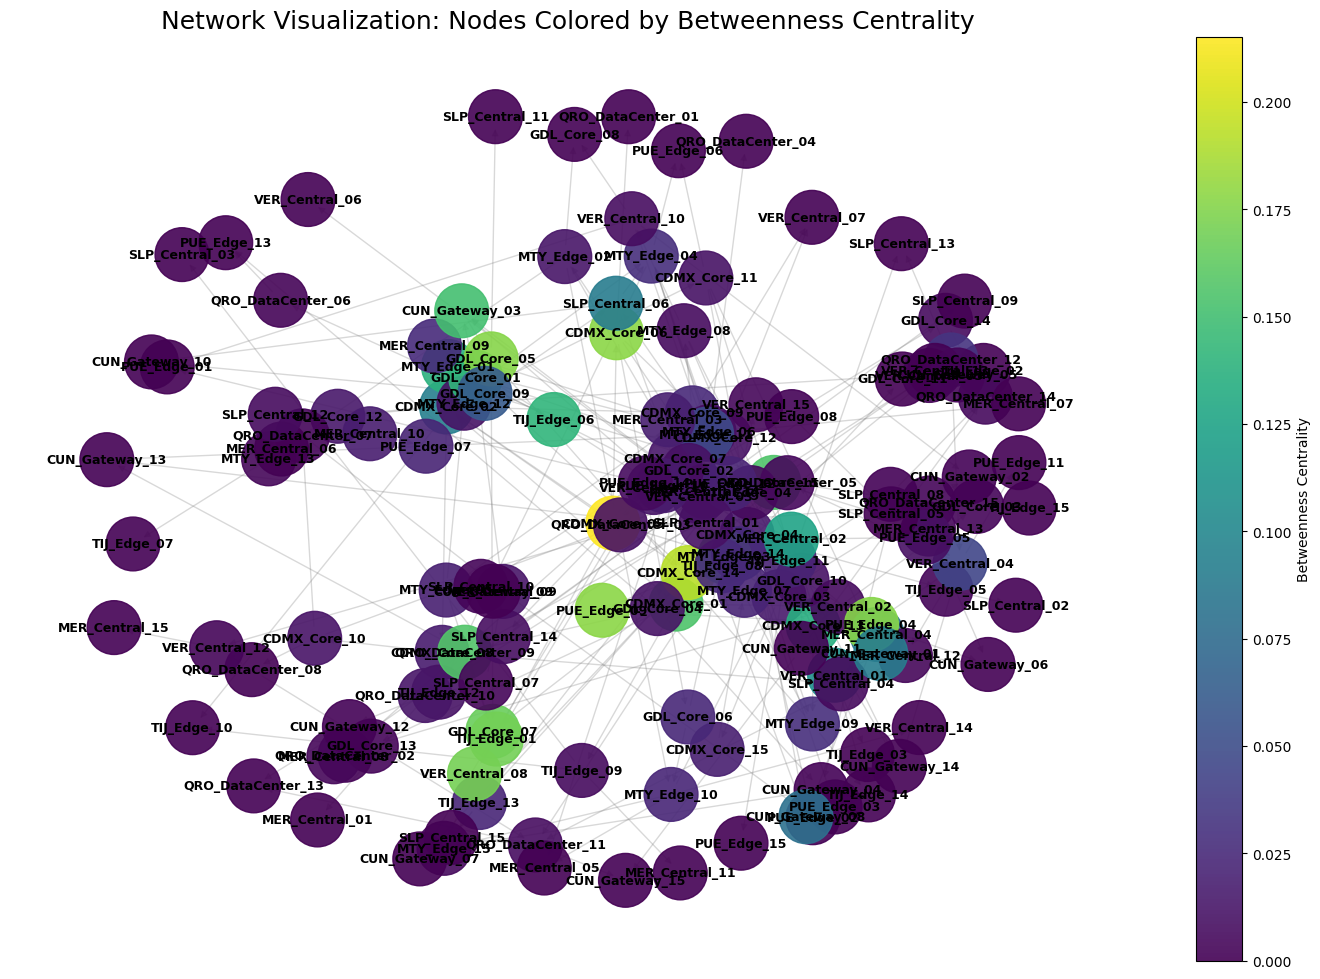

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

# Ensure G and betweenness_centrality are available from previous steps
# If not, ensure they are calculated before running this cell

plt.figure(figsize=(18, 12)) # Increase figure size for better visibility

# Use a spring layout for better visualization of interconnected nodes
# Adjust k (optimal distance between nodes) and iterations for a stable layout
pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)

# Create a list of node colors based on betweenness centrality values
# Normalize centrality values for coloring
node_colors = [betweenness_centrality[node] for node in G.nodes()]

# Draw nodes with colors proportional to their betweenness centrality
# cmap='viridis' is a good choice for showing intensity, set vmin/vmax for consistent color mapping
# node_size can also be varied by centrality for further emphasis
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               cmap=plt.cm.viridis, node_size=1500, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.3, edge_color='gray')

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')

# Draw edge labels (latency) - optional, can clutter for large graphs
# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)

# Add a color bar to explain the node coloring based on betweenness centrality
cbar = plt.colorbar(nodes)
cbar.set_label('Betweenness Centrality')

plt.title('Network Visualization: Nodes Colored by Betweenness Centrality', size=18)
plt.axis('off') # Hide axes
plt.show()

### Calculation of X = Muestras QGT / Muestras FastGTN

In [9]:
# Using the predefined values based on previous data splits
muestras_qgt = 700
muestras_fastgtn = 105

x_value = muestras_qgt / muestras_fastgtn

print(f"The value of x (Muestras QGT / Muestras FastGTN) is: {x_value:.4f}")

The value of x (Muestras QGT / Muestras FastGTN) is: 6.6667


### Scatter Plot: Latency vs. Speed

Let's visualize the relationship between network latency (`Latencia_ms`) and speed (`Velocidad_Mbps`) using a scatter plot. This can help identify if higher latency is associated with lower speeds, or vice versa, and reveal any patterns in the data.

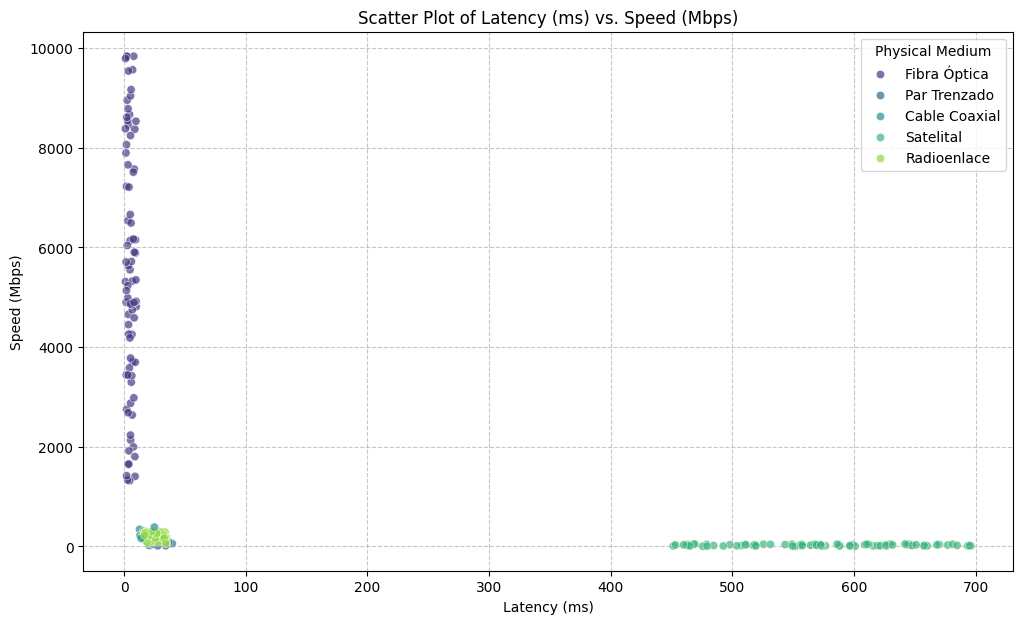

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Latencia_ms', y='Velocidad_Mbps', data=df, hue='Medio_Fisico', palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Latency (ms) vs. Speed (Mbps)')
plt.xlabel('Latency (ms)')
plt.ylabel('Speed (Mbps)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Physical Medium')
plt.show()

### Interpretation of the Bar Chart

From the bar chart, we can observe the following:

*   **Accuracy:** The original FastGTN model had a very high accuracy (97.78%), but this was misleading due to class imbalance.
    The weighted model's accuracy dropped significantly (2.22%).

*   **Precision:** Both models show very low precision. The original FastGTN had 0% precision, indicating it made no correct positive predictions (or no positive predictions at all). The weighted model also has extremely low precision (2.22%), meaning that when it predicts a positive class, it is very often incorrect.

*   **Recall:** This is where the class weighting made a dramatic difference. The original FastGTN had 0% recall, completely failing to identify any positive instances. The weighted model achieved 100% recall, meaning it successfully identified all actual positive instances.

*   **F1-Score:** The F1-Score, a harmonic mean of precision and recall, was 0% for the original model. For the weighted model, it improved to 4.35%, which is still very low due to the poor precision.

**Conclusion:**

Class weighting successfully forced the model to identify the minority class (100% recall), but it did so at the expense of precision and overall accuracy. The model became over-sensitive to the minority class, leading to a high number of false positives. This indicates that while class weighting addressed the recall issue, it overcorrected and created a new problem of high false positive rates and low precision. Further optimization is needed to find a better balance between identifying positive cases and not making too many incorrect positive predictions.